# Analysis of different implementations to improve MPPI performance

In [247]:
# === Setup: everything Parts 2b-2e need (the rest of the notebook was removed) ===
import numpy as np
import matplotlib.pyplot as plt

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import SAMPLING_CONTROLLERS

# shared pendulum task + backend (Parts 2c/2d/2e build their own per-env backends)
TASK_NAME = "pendulum"
task = make_task(TASK_NAME)
backend = MujocoBackend(task.model_path)
print(f"task={TASK_NAME}  nq={task.nq} nv={task.nv} nu={task.nu} dt={backend.dt}")

# one controller instance: used only for its horizon grid (ctrl.t_eval, ctrl.H)
COMMON = dict(num_samples=5, num_knots=11, plan_horizon=1.0,
              spline_type="zero", iterations=1, seed=0)
ctrl = SAMPLING_CONTROLLERS["mppi"](task, backend, **COMMON,
                                    noise_level=0.5, temperature=1.0)
H, nu, K = ctrl.H, task.nu, COMMON["num_samples"]


def sample_horizon(K, H, nu, u_min, u_max, rng, dist="uniform", scale=1.0):
    """K action sequences (K, H, nu), iid across the H horizon steps.

    dist: "uniform" -> Uniform(u_min,u_max); "gaussian" -> N(0,scale^2) clipped;
          "bernoulli" -> bang-bang over {u_min,u_max}.
    """
    u_min = np.asarray(u_min, dtype=np.float64)
    u_max = np.asarray(u_max, dtype=np.float64)
    if dist == "uniform":
        return rng.uniform(u_min, u_max, size=(K, H, nu))
    if dist == "gaussian":
        return np.clip(rng.normal(0.0, scale, size=(K, H, nu)), u_min, u_max)
    if dist == "bernoulli":
        return np.where(rng.random((K, H, nu)) < 0.5, u_min, u_max).astype(np.float64)
    raise ValueError(f"unknown dist {dist!r}")


# uniform-horizon control samples that Parts 2b/2c descend from (gaussian-drawn, seed 0)
rng = np.random.default_rng(0)
controls_uni = sample_horizon(K, H, nu, task.u_min, task.u_max, rng, dist="gaussian")
print(f"controls_uni: shape={controls_uni.shape}  (K={K}, H={H}, nu={nu})")


task=pendulum  nq=1 nv=1 nu=1 dt=0.02
controls_uni: shape=(5, 50, 1)  (K=5, H=50, nu=1)


## Part 2b — Gradient descent on **cost** (finite differences)

Unlike smoothness, the cost is **not** an explicit function of `u`: it depends on `u`
only through the rolled-out trajectory,

$$J(u)=\sum_t \ell(x_t,u_t)+\ell_T(x_H),\qquad x_{t+1}=f(x_t,u_t),$$

so each $u_t$ moves $J$ directly (control terms) **and** indirectly through every
downstream state. There is no closed-form Laplacian — we differentiate through the
MuJoCo rollout with **central finite differences**, stacking all $H\,n_u$ coordinate
perturbations into the batch dimension so one full gradient costs exactly **two**
`backend.rollout` calls. The clip-to-bounds GD loop is otherwise identical to Part 2.

### How the gradient scales from step to step

Near a (local) minimum $u^\star$ the cost is locally quadratic,
$J(u)\approx J^\star+\tfrac12\,e^\top H\,e$ with $e=u-u^\star$, so the gradient is
$g\approx H e$ and one GD step is a *linear* map on it:

$$e_{t+1}=(I-\eta H)\,e_t \;\Longrightarrow\; g_{t+1}\approx(I-\eta H)\,g_t,\qquad
\frac{\lVert g_{t+1}\rVert}{\lVert g_t\rVert}\to\rho=\max_k\lvert1-\eta\lambda_k\rvert,$$

where $\lambda_k$ are the eigenvalues (curvatures) of the cost Hessian $H$. That single
ratio $\rho$ governs everything:

- **$\rho<1$ — geometric decay.** Inside a smooth basin $\lVert g_t\rVert$ shrinks by a
  constant factor each step (a straight line on a log axis). The slowest direction,
  $\rho\approx1-\eta\lambda_{\min}$, sets the rate; conditioning
  $\kappa=\lambda_{\max}/\lambda_{\min}$ pushes $\rho\to1$ (slow).
- **Step ceiling.** Stability needs $\eta<2/\lambda_{\max}$. There is *no* universal
  safe $\eta\le0.25$ like the smoothness Laplacian — overshoot in any direction and
  $\rho>1$, so the gradient *amplifies* every step and GD diverges.
- **$\rho>1$ off a plateau.** Far from a minimum the quadratic model fails. In **this
  swing-up demo** that is exactly what you see: from rest the cost is nearly flat
  ($\lVert g_0\rVert\approx0.3$), and as descent drives the controls into the dynamic
  regime the landscape steepens, so the gradient *grows* at a roughly constant
  $\rho\approx1.12$/step for the first ~20 iterations.
- **Constraint stall.** It then plateaus (ratio $\to1$) — not at a minimum, but because
  most control samples have hit $[u_\min,u_\max]$; projected GD freezes those clamped
  coordinates, so the active gradient stops changing. This flat-plus-clipped landscape
  is precisely why sampling/MPPI is used here instead of first-order descent.

The cell below plots $\lVert\partial J/\partial u\rVert$ on a log axis and prints the mean
step ratio for the early vs. late phases, so you can read $\rho$ off directly.


In [248]:
# --- Cost as a function of the control sequence (mirrors _score_normal) --------
def total_cost(controls, state, task, backend):
    """J per rollout (lower = better).  controls: (B, H, nu) -> (B,).

    Same aggregation as SamplingController._score_normal: sum of running-cost
    terms over (H, n_terms) plus the terminal-cost terms."""
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
    return running + terminal


def cost_grad(controls, state, task, backend, eps=1e-4):
    """Central-difference dJ/du through the rollout.  (K, H, nu) -> same shape.

    All H*nu coordinate perturbations are stacked into the batch dimension, so
    the whole gradient costs exactly TWO backend.rollout calls (the +/- sides)."""
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps     # (P, H, nu) one-hots
    base = controls[:, None]                                          # (K, 1, H, nu)
    plus  = (base + bump).reshape(K * P, H, nu)
    minus = (base - bump).reshape(K * P, H, nu)
    Jp = total_cost(plus,  state, task, backend).reshape(K, P)
    Jm = total_cost(minus, state, task, backend).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)


def cost_descent(u, state, task, backend, n_iter, lr, eps=1e-4):
    """Projected GD on J (clip to bounds each step).  Mirrors smooth_descent.

    Returns (u_final, J_hist, gnorm_hist):
      J_hist     (n_iter + 1, K)  cost per rollout, row 0 = initial
      gnorm_hist (n_iter,     K)  ||dJ/du|| per rollout at each step (pre-step)"""
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    K = u.shape[0]
    J_hist = np.empty((n_iter + 1, K)); J_hist[0] = total_cost(u, state, task, backend)
    g_hist = np.empty((n_iter, K))
    for t in range(n_iter):
        g = cost_grad(u, state, task, backend, eps)
        g_hist[t] = np.linalg.norm(g.reshape(K, -1), axis=1)
        u -= lr * g
        np.clip(u, task.u_min, task.u_max, out=u)
        J_hist[t + 1] = total_cost(u, state, task, backend)
    return u, J_hist, g_hist


cost GD: n_iter=50, lr=0.2
  rollout 0: J   203.941 ->   187.589    |g|   0.367 ->   2.875
  rollout 1: J   203.968 ->   187.274    |g|   0.214 ->   2.885
  rollout 2: J   203.941 ->   187.148    |g|   0.340 ->   2.889
  rollout 3: J   203.884 ->   187.427    |g|   0.272 ->   2.887
  rollout 4: J   203.902 ->   187.375    |g|   0.379 ->   2.882
  mean step ratio ||g_t+1||/||g_t|| (rho): early(0:20)=1.110  late(20:)=1.005
  fraction of control samples at a bound (final): 0.86


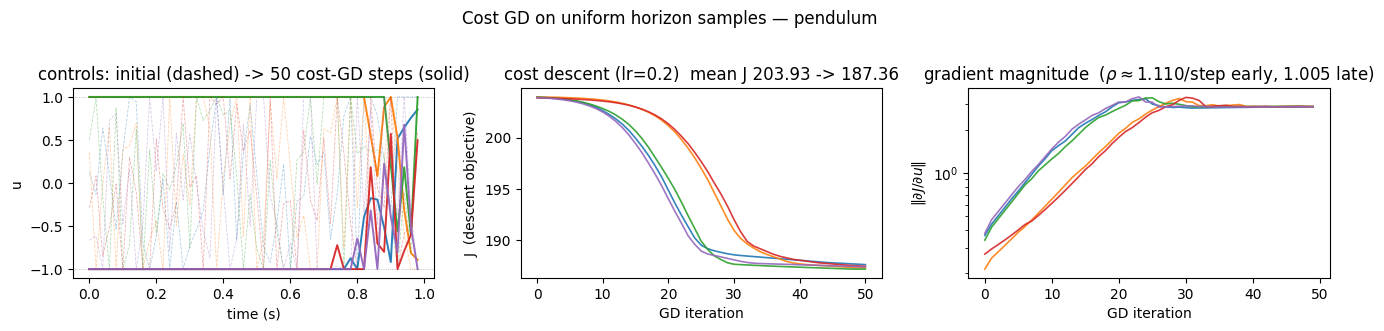

In [249]:
# Descend the Part-1 uniform samples on COST (not smoothness). Same initial
# controls (controls_uni) and the same clip-to-bounds projection as Part 2,
# but the gradient now flows through the MuJoCo rollout (finite differences).
state0 = backend.get_state()          # reset state = pendulum hanging down (theta=0)

N_ITER_J = 50
LR_J     = 0.2

controls_costgd, J_hist, G_hist = cost_descent(
    controls_uni, state0, task, backend, n_iter=N_ITER_J, lr=LR_J,
)

J0, Jf = J_hist[0], J_hist[-1]
# step-to-step contraction factor rho ~ ||g_{t+1}|| / ||g_t||  (averaged over rollouts)
gnorm_mean = G_hist.mean(axis=1)                                  # (n_iter,)
ratios = gnorm_mean[1:] / np.maximum(gnorm_mean[:-1], 1e-12)
at_bound = np.mean((controls_costgd <= task.u_min + 1e-9) |
                   (controls_costgd >= task.u_max - 1e-9))

print(f"cost GD: n_iter={N_ITER_J}, lr={LR_J}")
for k in range(K):
    print(f"  rollout {k}: J {J0[k]:9.3f} -> {Jf[k]:9.3f}    "
          f"|g| {G_hist[0, k]:7.3f} -> {G_hist[-1, k]:7.3f}")
print(f"  mean step ratio ||g_t+1||/||g_t|| (rho): "
      f"early(0:20)={ratios[:20].mean():.3f}  late(20:)={ratios[20:].mean():.3f}")
print(f"  fraction of control samples at a bound (final): {at_bound:.2f}")

# --- three-panel figure: controls, cost-vs-iter, gradient-norm-vs-iter ---------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2))

ax = axes[0]
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for k in range(K):
    color = prop_cycle[k % len(prop_cycle)]
    for j in range(nu):
        ax.plot(ctrl.t_eval, controls_uni[k, :, j],    color=color, lw=0.6, ls="--", alpha=0.35)
        ax.plot(ctrl.t_eval, controls_costgd[k, :, j], color=color, lw=1.4, alpha=0.95)
for j in range(nu):
    ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
ax.set_title(f"controls: initial (dashed) -> {N_ITER_J} cost-GD steps (solid)")
ax.set_xlabel("time (s)"); ax.set_ylabel("u")

ax = axes[1]
ax.plot(J_hist, lw=1.2, alpha=0.9)
ax.set_xlabel("GD iteration"); ax.set_ylabel("J  (descent objective)")
ax.set_title(f"cost descent (lr={LR_J})  mean J {J0.mean():.2f} -> {Jf.mean():.2f}")

ax = axes[2]
ax.plot(G_hist, lw=1.2, alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("GD iteration"); ax.set_ylabel(r"$\|\partial J/\partial u\|$")
ax.set_title(rf"gradient magnitude  ($\rho\approx${ratios[:20].mean():.3f}/step early, "
             rf"{ratios[20:].mean():.3f} late)")

fig.suptitle(f"Cost GD on uniform horizon samples — {TASK_NAME}", y=1.02)
fig.tight_layout()
plt.show()


            term |      non-GD          GD   delta
      theta_cost |    203.8671    186.7163   -17.1508
  theta_dot_cost |      0.0337      0.6010   +0.5674
    control_cost |      0.0266      0.0454   +0.0189
           total |    203.9273    187.3627   -16.5646


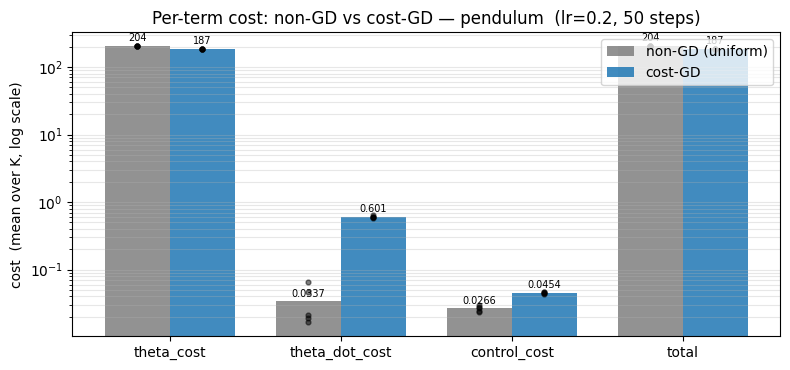

In [ ]:
# Per-term cost: non-GD (uniform samples) vs the cost-GD result.
# Each term's total = running summed over the horizon + its terminal contribution
# (same aggregation as total_cost / _score_normal), reported per rollout so the
# three pendulum terms -- theta_cost, theta_dot_cost, control_cost -- and their
# sum can be compared side by side.
def cost_term_breakdown(controls, state, task, backend):
    """Per-term total cost.  controls: (B, H, nu) -> (B, n_terms)."""
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=1)   # (B, n_terms)
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1])    # (B, n_terms)
    return running + terminal


terms_uni = cost_term_breakdown(controls_uni,    state0, task, backend)   # (K, n_terms)
terms_gd  = cost_term_breakdown(controls_costgd, state0, task, backend)   # (K, n_terms)

labels   = list(task.cost_term_names) + ["total"]
mean_uni = np.append(terms_uni.mean(0), terms_uni.sum(1).mean())
mean_gd  = np.append(terms_gd.mean(0),  terms_gd.sum(1).mean())
roll_uni = np.column_stack([terms_uni, terms_uni.sum(1)])   # per-rollout incl. total
roll_gd  = np.column_stack([terms_gd,  terms_gd.sum(1)])

print(f"{'term':>16s} | {'non-GD':>11s} {'GD':>11s}   delta")
for i, name in enumerate(labels):
    print(f"{name:>16s} | {mean_uni[i]:11.4f} {mean_gd[i]:11.4f}   {mean_gd[i]-mean_uni[i]:+.4f}")

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.8))
b1 = ax.bar(x - w/2, mean_uni, w, label="non-GD (uniform)", color="tab:gray", alpha=0.85)
b2 = ax.bar(x + w/2, mean_gd,  w, label="cost-GD",          color="tab:blue", alpha=0.85)
# per-rollout dots so the spread across the K samples is visible (terms span
# orders of magnitude -> log y-axis)
for i in range(len(labels)):
    ax.scatter(np.full(K, x[i] - w/2), roll_uni[:, i], s=12, color="k", alpha=0.5, zorder=3)
    ax.scatter(np.full(K, x[i] + w/2), roll_gd[:, i],  s=12, color="k", alpha=0.5, zorder=3)
ax.bar_label(b1, fmt="%.3g", padding=2, fontsize=7)
ax.bar_label(b2, fmt="%.3g", padding=2, fontsize=7)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("cost  (mean over K, log scale)")
ax.set_title(f"Per-term cost: MPPI vs MPPI+GD — {TASK_NAME}  (lr={LR_J}, {N_ITER_J} steps)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3, which="both")
fig.tight_layout()
plt.show()


## Part 2c — Per-term cost (uniform vs cost-GD) on hopper, walker & g1

The same per-term comparison as the pendulum cell above, repeated for the **hopper**,
**walker**, and **g1**. The cell builds a fresh `task` + `backend` per environment and
reuses `cost_descent` / `cost_term_breakdown` unchanged. One subplot per term (+ total)
on a linear, per-term axis, since the terms span very different magnitudes.

Caveats worth knowing:
- For the **walker**, `orientation_cost` has weight `0.0` in the task (`walker.py:53`), so
  it is ~0 *by construction* and reads flat here. (It does show up in the fulfillment plot
  below, where orientation is scored regardless of the cost weight.)
- **g1** is contact-rich and 29-dimensional, so its finite-difference gradient is noisy
  and plain GD wanders / does not reliably reduce cost — the bars mostly document that
  failure mode. It is also slow: **~9.6 s per gradient**, so the g1 block alone is ~1 min
  even at `n_iter=6`. The whole cell takes ~2 min. Lower `n_iter` in `ENV_GD` to taste.



[hopper]  cost-GD lr=0.05 n_iter=30   mean total J 3758.241 -> 1223.740
              term |      uniform      cost-GD   delta
       height_cost |     356.9065     329.8875   -27.0190
  orientation_cost |    3333.2904     759.2416   -2574.0489
     velocity_cost |      44.5842     106.4903   +61.9061
      control_cost |      23.4600      28.1204   +4.6604
             total |    3758.2411    1223.7397   -2534.5014


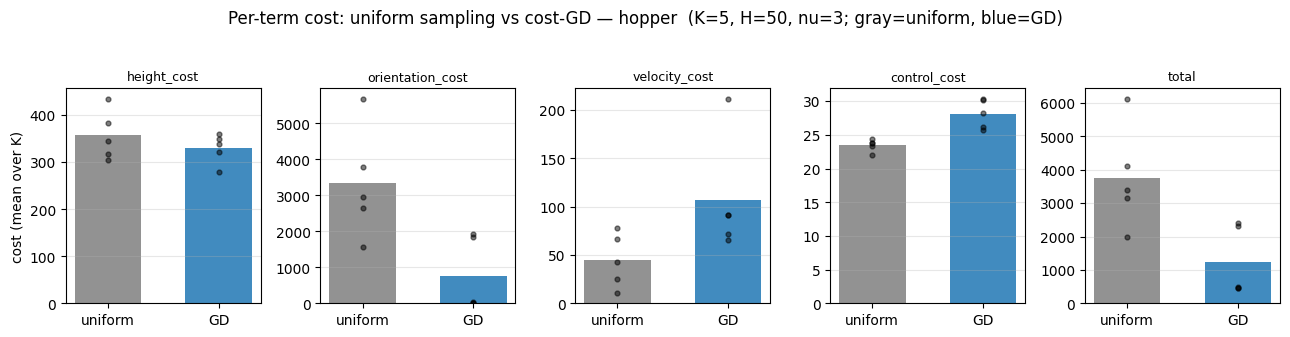


[walker]  cost-GD lr=0.05 n_iter=20   mean total J 602.052 -> 574.900
              term |      uniform      cost-GD   delta
       height_cost |     311.2540     294.7698   -16.4842
  orientation_cost |       0.0000       0.0000   +0.0000
     velocity_cost |     290.7985     280.1303   -10.6682
      control_cost |       0.0000       0.0000   +0.0000
             total |     602.0525     574.9001   -27.1524


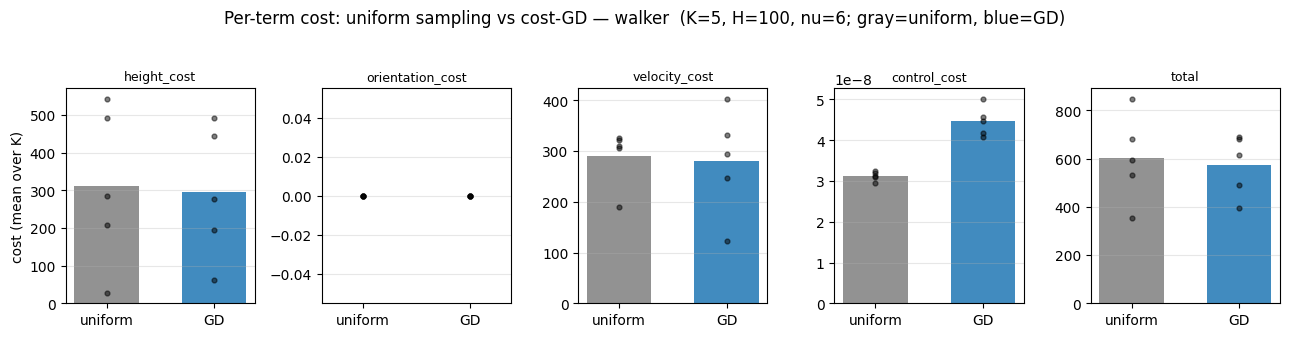

In [ ]:
# Per-term cost comparison (cost-GD vs uniform sampling) for HOPPER, WALKER and
# G1, mirroring the pendulum cell above. Reuses cost_descent / cost_term_breakdown
# (both parameterized by (task, backend)) on a fresh task+backend per environment.
# One subplot per cost term (+ total) with a linear, per-term y-axis.
#
# Timing / behaviour notes:
#   walker ~1.6 s/grad (nu=6, H=100);  g1 ~9.6 s/grad (nu=29) and GD is unstable
#   (noisy contact gradients) -> small lr / few iters for g1. Whole cell ~2 min.
ENV_GD = {
    "hopper":     dict(lr=0.05, n_iter=30),
    "walker":     dict(lr=0.05, n_iter=20),
    "g1_standup": dict(lr=0.01, n_iter=6),   # contact-rich: GD barely moves / wanders
}
K_ENV, PLAN_H, SEED = 5, 1.0, 0

for env_name, gd in ENV_GD.items():
    task_e    = make_task(env_name)
    backend_e = MujocoBackend(task_e.model_path)
    H_e, nu_e = round(PLAN_H / backend_e.dt), task_e.nu
    state_e   = backend_e.get_state()

    rng = np.random.default_rng(SEED)
    controls_uni_e = sample_horizon(K_ENV, H_e, nu_e, task_e.u_min, task_e.u_max,
                                    rng, dist="gaussian")
    controls_gd_e, _, _ = cost_descent(
        controls_uni_e, state_e, task_e, backend_e, n_iter=gd["n_iter"], lr=gd["lr"],
    )

    terms_uni = cost_term_breakdown(controls_uni_e, state_e, task_e, backend_e)   # (K, n_terms)
    terms_gd  = cost_term_breakdown(controls_gd_e,  state_e, task_e, backend_e)
    cols_uni  = np.column_stack([terms_uni, terms_uni.sum(1)])                    # + total column
    cols_gd   = np.column_stack([terms_gd,  terms_gd.sum(1)])
    labels    = list(task_e.cost_term_names) + ["total"]

    print(f"\n[{env_name}]  cost-GD lr={gd['lr']} n_iter={gd['n_iter']}   "
          f"mean total J {terms_uni.sum(1).mean():.3f} -> {terms_gd.sum(1).mean():.3f}")
    print(f"{'term':>18s} | {'uniform':>12s} {'cost-GD':>12s}   delta")
    for i, name in enumerate(labels):
        u, g = cols_uni[:, i].mean(), cols_gd[:, i].mean()
        print(f"{name:>18s} | {u:12.4f} {g:12.4f}   {g - u:+.4f}")

    n = len(labels)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.2))
    for i, (ax, name) in enumerate(zip(axes, labels)):
        ax.bar([0], [cols_uni[:, i].mean()], 0.6, color="tab:gray", alpha=0.85)
        ax.bar([1], [cols_gd[:, i].mean()],  0.6, color="tab:blue", alpha=0.85)
        ax.scatter(np.zeros(K_ENV), cols_uni[:, i], s=12, color="k", alpha=0.5, zorder=3)
        ax.scatter(np.ones(K_ENV),  cols_gd[:, i],  s=12, color="k", alpha=0.5, zorder=3)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["uniform", "GD"])
        ax.set_title(name, fontsize=9); ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("cost (mean over K)")
    fig.suptitle(f"Per-term cost: uniform sampling vs cost-GD — {env_name}  "
                 f"(K={K_ENV}, H={H_e}, nu={nu_e}; gray=uniform, blue=GD)", y=1.04)
    fig.tight_layout()
    plt.show()


## Part 2d — FPL + GD: **`fpl_cost` (no discount, γ = 1)**

The same finite-difference gradient descent as Part 2b, but the objective is the **FPL
fulfillment reward** in the `fpl_cost` sense: at each timestep take the power-mean over the
fulfillment terms (`fpl_p = 0.1`, near-geometric → dominated by the weakest term *that
step*), then combine those per-step scores over time with a **uniform mean (no discount,
γ = 1)**. GD **ascends the reward** (`u += lr · ∂reward/∂u`). The bars show per-term
fulfillment (aggregated the same way) plus the optimized scalar reward on the right.

**Convention used throughout this notebook:** `fpl_cost` and `fpl_discounted` use the
**same per-step aggregation** (power-mean over terms each step) and differ **only by the
time discount** — `fpl_cost` → γ = 1 (this cell), `fpl_discounted` → γ = 0.99 (Part 2e).
This is a discount on/off toggle; it is *not* the aggregation-order distinction that
`SamplingController._score_fpl` draws between its two modes. The **companion cell below
(Part 2e)** is identical except γ = 0.99. Runs all four envs; **g1 is slow (~9.6 s/grad)
and barely moves**, so the whole cell is ~1.5 min.


In [ ]:
# Part 2d -- FPL + GD with **fpl_cost = NO discount (gamma=1)**: objective = the FPL
# fulfillment reward aggregated as power-mean over terms PER STEP, then a UNIFORM MEAN
# over time (no discount factor). Companion to Part 2e, which uses the SAME per-step
# aggregation but WITH a gamma=0.99 discount -- the two cells differ ONLY by the discount.
from analytic_mppi.tasks import power_mean

def fd_grad(objective, controls, eps=1e-4):
    """Central-difference gradient of a generic (B,H,nu)->(B,) objective.
    Stacks all H*nu perturbations into the batch dim -> 2 rollouts per gradient."""
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps
    base = controls[:, None]
    Jp = objective((base + bump).reshape(K * P, H, nu)).reshape(K, P)
    Jm = objective((base - bump).reshape(K * P, H, nu)).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)


def _rollout_terms_f(controls, state, task, backend):
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    run  = task.running_cost_terms_f(qpos, qvel, sensordata, controls)              # (B,H,n_run)
    term = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])  # (B,n_term)
    return run, term


def fpl_reward(controls, state, task, backend, discount, p=0.1, gamma=0.99):
    """FPL reward in [0,1] (higher=better): power-mean over terms PER STEP, then aggregate
    over time.  discount=False -> uniform mean over time (gamma=1, 'fpl_cost');
    discount=True  -> gamma-discounted normalized sum over time ('fpl_discounted')."""
    run, term = _rollout_terms_f(controls, state, task, backend)
    per_step = power_mean(run, p)                                  # (B, H)  over terms
    if term.shape[-1] > 0:
        per_step = np.concatenate([per_step, power_mean(term, p)[:, None]], axis=1)
    if not discount:
        return per_step.mean(axis=1)                               # gamma=1, no discount
    L = per_step.shape[1]; d = gamma ** np.arange(L); norm = (1 - gamma) / (1 - gamma ** L)
    return (per_step * d[None, :]).sum(axis=1) * norm


def fpl_per_term(controls, state, task, backend, discount, gamma=0.99):
    """Per-term fulfillment in [0,1] aggregated over time (display metric), using the same
    discount setting as the reward: uniform mean (gamma=1) or gamma-discounted."""
    run, term = _rollout_terms_f(controls, state, task, backend)
    H, n_run = run.shape[1], run.shape[-1]; n_term = term.shape[-1]; H1 = H + 1
    if discount:
        wf = gamma ** np.arange(H1); nf = (1 - gamma) / (1 - gamma ** H1)
        wr = gamma ** np.arange(H);  nr = (1 - gamma) / (1 - gamma ** H) if H > 1 else 1.0
    else:
        wf = np.ones(H1); nf = 1.0 / H1
        wr = np.ones(H);  nr = 1.0 / H
    cols = []
    if n_term > 0:
        ext = np.concatenate([run[..., :n_term], term[:, None, :]], axis=1)         # (B,H+1,n_term)
        cols.append((ext * wf[:, None]).sum(axis=1) * nf)
    if n_run > n_term:
        cols.append((run[..., n_term:] * wr[:, None]).sum(axis=1) * nr)
    return np.concatenate(cols, axis=-1)


def fpl_descent(u, state, task, backend, n_iter, lr, discount, p=0.1, eps=1e-4):
    """Projected gradient ASCENT on the FPL reward (clip to bounds each step)."""
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    obj = lambda c: -fpl_reward(c, state, task, backend, discount, p)
    for _ in range(n_iter):
        u -= lr * fd_grad(obj, u, eps)
        np.clip(u, task.u_min, task.u_max, out=u)
    return u


FPL_DISCOUNT = False     # Part 2d: fpl_cost == NO discount (gamma = 1, uniform mean over time)
FPL_GD = {
    "pendulum":   dict(lr=2.0, n_iter=30),
    "hopper":     dict(lr=2.0, n_iter=20),
    "walker":     dict(lr=2.0, n_iter=15),
    "g1_standup": dict(lr=2.0, n_iter=6),    # ~9.6 s/grad, noisy -> barely moves
}
K_F, PLAN_H_F, SEED_F, FPL_P = 5, 1.0, 0, 0.1

for env_name, gd in FPL_GD.items():
    task_f    = make_task(env_name)
    backend_f = MujocoBackend(task_f.model_path)
    H_f, nu_f = round(PLAN_H_F / backend_f.dt), task_f.nu
    state_f   = backend_f.get_state()

    rng = np.random.default_rng(SEED_F)
    controls_uni_f = sample_horizon(K_F, H_f, nu_f, task_f.u_min, task_f.u_max,
                                    rng, dist="gaussian")
    controls_gd_f  = fpl_descent(controls_uni_f, state_f, task_f, backend_f,
                                 n_iter=gd["n_iter"], lr=gd["lr"], discount=FPL_DISCOUNT, p=FPL_P)

    f_uni = fpl_per_term(controls_uni_f, state_f, task_f, backend_f, FPL_DISCOUNT)   # (K, n_terms_f)
    f_gd  = fpl_per_term(controls_gd_f,  state_f, task_f, backend_f, FPL_DISCOUNT)
    R_uni = fpl_reward(controls_uni_f, state_f, task_f, backend_f, FPL_DISCOUNT, FPL_P)   # (K,)
    R_gd  = fpl_reward(controls_gd_f,  state_f, task_f, backend_f, FPL_DISCOUNT, FPL_P)
    cols_uni = np.column_stack([f_uni, R_uni])
    cols_gd  = np.column_stack([f_gd,  R_gd])
    labels   = list(task_f.cost_term_names_f) + ["reward (fpl_cost)"]

    print(f"\n[{env_name}]  fpl_cost-GD (gamma=1, NO discount) lr={gd['lr']} n_iter={gd['n_iter']}   "
          f"mean reward {R_uni.mean():.4f} -> {R_gd.mean():.4f}")
    print(f"{'fulfillment term':>22s} | {'uniform':>10s} {'fpl_cost-GD':>12s}   delta  (higher=better)")
    for i, name in enumerate(labels):
        u, g = cols_uni[:, i].mean(), cols_gd[:, i].mean()
        print(f"{name:>22s} | {u:10.4f} {g:12.4f}   {g - u:+.4f}")

    n = len(labels)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.2))
    for i, (ax, name) in enumerate(zip(axes, labels)):
        ax.bar([0], [cols_uni[:, i].mean()], 0.6, color="tab:gray",   alpha=0.85)
        ax.bar([1], [cols_gd[:, i].mean()],  0.6, color="tab:orange", alpha=0.85)
        ax.scatter(np.zeros(K_F), cols_uni[:, i], s=12, color="k", alpha=0.5, zorder=3)
        ax.scatter(np.ones(K_F),  cols_gd[:, i],  s=12, color="k", alpha=0.5, zorder=3)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["uniform", "GD"])
        ax.set_ylim(0, 1.02); ax.set_title(name, fontsize=9); ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("fulfillment (mean over K)  up=better")
    fig.suptitle(f"Per-term fulfillment + fpl_cost reward (gamma=1, NO discount): uniform vs GD — {env_name}  "
                 f"(K={K_F}, H={H_f}, nu={nu_f}; gray=uniform, orange=GD)", y=1.04)
    fig.tight_layout()
    plt.show()


## Part 2e — FPL + GD: **`fpl_discounted` (discount, γ = 0.99)**

Identical to Part 2d except the per-step fulfillment scores are combined over time with a
**γ = 0.99 discount** (normalized to `[0, 1]`) instead of a uniform mean. Same per-step
aggregation (power-mean over fulfillment terms each step, `fpl_p = 0.1`), same GD ascent on
the reward — **the only difference from Part 2d is the discount factor**, so comparing the
two cells isolates what discounting buys you.

(As noted in Part 2d, this `fpl_cost`/`fpl_discounted` split is a *discount on/off* toggle
on a fixed aggregation, not the aggregation-order distinction in
`SamplingController._score_fpl`.) Because every term lives in `[0, 1]`, the per-term bars
share one axis — so the walker's `orientation_fulfillment` shows up here even though its
*cost* weight is 0. Runs pendulum → hopper → walker → g1; **g1 is ~9.6 s/grad and barely
moves** (whole cell ~1.5 min).


In [ ]:
# Part 2e -- FPL + GD with **fpl_discounted = discount (gamma=0.99)**: the SAME per-step
# aggregation as Part 2d (power-mean over fulfillment terms PER STEP), but the per-step
# scores are combined over time with a gamma=0.99 discount instead of a uniform mean.
# The ONLY difference from Part 2d is the discount factor. Self-contained.
from analytic_mppi.tasks import power_mean

def fd_grad(objective, controls, eps=1e-4):
    """Central-difference gradient of a generic (B,H,nu)->(B,) objective.
    Stacks all H*nu perturbations into the batch dim -> 2 rollouts per gradient."""
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps
    base = controls[:, None]
    Jp = objective((base + bump).reshape(K * P, H, nu)).reshape(K, P)
    Jm = objective((base - bump).reshape(K * P, H, nu)).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)


def _rollout_terms_f(controls, state, task, backend):
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    run  = task.running_cost_terms_f(qpos, qvel, sensordata, controls)              # (B,H,n_run)
    term = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])  # (B,n_term)
    return run, term


def fpl_reward(controls, state, task, backend, discount, p=0.1, gamma=0.99):
    """FPL reward in [0,1] (higher=better): power-mean over terms PER STEP, then aggregate
    over time.  discount=False -> uniform mean over time (gamma=1, 'fpl_cost');
    discount=True  -> gamma-discounted normalized sum over time ('fpl_discounted')."""
    run, term = _rollout_terms_f(controls, state, task, backend)
    per_step = power_mean(run, p)                                  # (B, H)  over terms
    if term.shape[-1] > 0:
        per_step = np.concatenate([per_step, power_mean(term, p)[:, None]], axis=1)
    if not discount:
        return per_step.mean(axis=1)                               # gamma=1, no discount
    L = per_step.shape[1]; d = gamma ** np.arange(L); norm = (1 - gamma) / (1 - gamma ** L)
    return (per_step * d[None, :]).sum(axis=1) * norm


def fpl_per_term(controls, state, task, backend, discount, gamma=0.99):
    """Per-term fulfillment in [0,1] aggregated over time (display metric), using the same
    discount setting as the reward: uniform mean (gamma=1) or gamma-discounted."""
    run, term = _rollout_terms_f(controls, state, task, backend)
    H, n_run = run.shape[1], run.shape[-1]; n_term = term.shape[-1]; H1 = H + 1
    if discount:
        wf = gamma ** np.arange(H1); nf = (1 - gamma) / (1 - gamma ** H1)
        wr = gamma ** np.arange(H);  nr = (1 - gamma) / (1 - gamma ** H) if H > 1 else 1.0
    else:
        wf = np.ones(H1); nf = 1.0 / H1
        wr = np.ones(H);  nr = 1.0 / H
    cols = []
    if n_term > 0:
        ext = np.concatenate([run[..., :n_term], term[:, None, :]], axis=1)         # (B,H+1,n_term)
        cols.append((ext * wf[:, None]).sum(axis=1) * nf)
    if n_run > n_term:
        cols.append((run[..., n_term:] * wr[:, None]).sum(axis=1) * nr)
    return np.concatenate(cols, axis=-1)


def fpl_descent(u, state, task, backend, n_iter, lr, discount, p=0.1, eps=1e-4):
    """Projected gradient ASCENT on the FPL reward (clip to bounds each step)."""
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    obj = lambda c: -fpl_reward(c, state, task, backend, discount, p)
    for _ in range(n_iter):
        u -= lr * fd_grad(obj, u, eps)
        np.clip(u, task.u_min, task.u_max, out=u)
    return u


FPL_DISCOUNT = True      # Part 2e: fpl_discounted == discounted over time (gamma = 0.99)
FPL_GAMMA = 0.99
FPL_GD = {
    "pendulum":   dict(lr=2.0, n_iter=30),
    "hopper":     dict(lr=2.0, n_iter=20),
    "walker":     dict(lr=2.0, n_iter=15),
    "g1_standup": dict(lr=2.0, n_iter=6),    # ~9.6 s/grad, noisy -> barely moves
}
K_F, PLAN_H_F, SEED_F, FPL_P = 5, 1.0, 0, 0.1

for env_name, gd in FPL_GD.items():
    task_f    = make_task(env_name)
    backend_f = MujocoBackend(task_f.model_path)
    H_f, nu_f = round(PLAN_H_F / backend_f.dt), task_f.nu
    state_f   = backend_f.get_state()

    rng = np.random.default_rng(SEED_F)
    controls_uni_f = sample_horizon(K_F, H_f, nu_f, task_f.u_min, task_f.u_max,
                                    rng, dist="gaussian")
    controls_gd_f = fpl_descent(controls_uni_f, state_f, task_f, backend_f,
                                n_iter=gd["n_iter"], lr=gd["lr"], discount=FPL_DISCOUNT, p=FPL_P)

    f_uni = fpl_per_term(controls_uni_f, state_f, task_f, backend_f, FPL_DISCOUNT)   # (K, n_terms_f)
    f_gd  = fpl_per_term(controls_gd_f,  state_f, task_f, backend_f, FPL_DISCOUNT)
    R_uni = fpl_reward(controls_uni_f, state_f, task_f, backend_f, FPL_DISCOUNT, FPL_P)   # (K,)
    R_gd  = fpl_reward(controls_gd_f,  state_f, task_f, backend_f, FPL_DISCOUNT, FPL_P)
    cols_uni = np.column_stack([f_uni, R_uni])
    cols_gd  = np.column_stack([f_gd,  R_gd])
    labels   = list(task_f.cost_term_names_f) + ["reward (fpl_disc)"]

    print(f"\n[{env_name}]  fpl_discounted-GD (gamma={FPL_GAMMA}) lr={gd['lr']} n_iter={gd['n_iter']}   "
          f"mean reward {R_uni.mean():.4f} -> {R_gd.mean():.4f}")
    print(f"{'fulfillment term':>22s} | {'uniform':>10s} {'fpl_disc-GD':>12s}   delta  (higher=better)")
    for i, name in enumerate(labels):
        u, g = cols_uni[:, i].mean(), cols_gd[:, i].mean()
        print(f"{name:>22s} | {u:10.4f} {g:12.4f}   {g - u:+.4f}")

    n = len(labels)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.2))
    for i, (ax, name) in enumerate(zip(axes, labels)):
        ax.bar([0], [cols_uni[:, i].mean()], 0.6, color="tab:gray",  alpha=0.85)
        ax.bar([1], [cols_gd[:, i].mean()],  0.6, color="tab:green", alpha=0.85)
        ax.scatter(np.zeros(K_F), cols_uni[:, i], s=12, color="k", alpha=0.5, zorder=3)
        ax.scatter(np.ones(K_F),  cols_gd[:, i],  s=12, color="k", alpha=0.5, zorder=3)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["uniform", "GD"])
        ax.set_ylim(0, 1.02); ax.set_title(name, fontsize=9); ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("fulfillment (mean over K)  ↑ better")
    fig.suptitle(f"Per-term fulfillment + fpl_discounted reward (gamma={FPL_GAMMA}): uniform vs GD — {env_name}  "
                 f"(K={K_F}, H={H_f}, nu={nu_f}; gray=uniform, green=GD)", y=1.04)
    fig.tight_layout()
    plt.show()


## Part 3 — Closed-loop: MPPI vs GD-MPPI (top-k combine) vs single-best GD, on every env

Parts 2b–2e ran gradient descent **open-loop** on a fixed sample set and only *compared*
rollouts. Part 3 closes the loop on **pendulum, hopper, and walker**: each method is a
receding-horizon controller that, every step, perturbs a nominal control sequence, scores
the `K` candidates, collapses them to one sequence, executes the first action,
warm-starts, and repeats. The three methods differ in **exactly one thing — the collapse
rule**:

| method | how the K rollouts become the next nominal |
|---|---|
| **`mppi`** | softmax-weighted average over **all** `K` rollouts, $w_k\propto e^{-(J_k-\min J)/\lambda}$. No GD. Reproduces [`mppi.py`](analytic_mppi/controllers/mppi.py). |
| **`topk_gd`** | keep the `top_k` lowest-cost rollouts, run `gd_iters` steps of cost-GD on **each** (Part 2b `cost_descent`), then softmax-combine the descended `top_k`. |
| **`best_gd`** | take the single best (`argmin`) rollout, GD it, execute it — no combining. |

**What "realized J" means.** It is the running cost *actually accrued on the executed
closed-loop trajectory* — **not** the planner's score. The planner (`total_cost`) scores a
hypothetical `H`-step open-loop rollout from the current state (plus a terminal term);
realized J instead sums, over every executed step `t`, the task's running-cost terms at
the state the system *actually reached* under the action it *actually applied*:
$J_{\text{real}}=\sum_{t}\sum_{\text{terms}}\ell(x_{t+1}, u_t)$. We recompute each
executed step's `sensordata` with a one-step `backend.rollout` (so hopper/walker's
height/velocity/orientation sensors are populated exactly as the planner would see them).
Lower = better; it is the honest "how well did the controller actually do" metric.

**Same noise across methods.** At step `t` every controller draws the **same** perturbation
tensor from `default_rng([SEED_P3, t])`, so the `K` candidates are identical across methods
at every step; only the collapse rule (and hence the nominal they perturb) differs. All
three share one cost (`total_cost`) and one softmax temperature per env, so the comparison
isolates the collapse rule.

**Per-env settings** (`ENV_CFG`) trade quality vs. runtime: walker uses a shorter 0.5 s
horizon and fewer GD iters because its finite-difference gradient costs ~0.3 s each. The
GD methods are ~10–30× slower per step than MPPI — **the whole cell takes ~3–4 min**
(pendulum ~15 s, hopper ~80 s, walker ~110 s). The headline result is instructive: GD
sharpening **helps on the smooth pendulum** but **hurts on the contact-rich hopper/walker**,
where finite-difference gradients are noisy — the same constraint-stall / noisy-gradient
failure documented in Parts 2b–2c, now visible in closed loop (and worst for `best_gd`,
which has no averaging to damp a bad gradient step).


In [ ]:
import time
# Part 3: three closed-loop controllers (mppi / topk_gd / best_gd) on pendulum, hopper,
# walker. Reuses total_cost + cost_descent from Part 2b; differs ONLY in the collapse rule.
# All methods share the same per-step noise (default_rng([SEED_P3, t])). Whole cell ~3-4 min.

SEED_P3, N_SAMPLES = 0, 32
METHODS = ("mppi", "topk_gd", "best_gd")
COLORS  = {"mppi": "tab:blue", "topk_gd": "tab:orange", "best_gd": "tab:green"}
ENV_CFG = {   # per-env: horizon, closed-loop steps, GD knobs, noise std, MPPI temperature
    "pendulum": dict(plan_horizon=1.0, T=200, top_k=4, gd_iters=4, gd_lr=0.20, sigma=0.5, lam=1.0),
    "hopper":   dict(plan_horizon=1.0, T=150, top_k=4, gd_iters=3, gd_lr=0.05, sigma=0.5, lam=10.0),
    "walker":   dict(plan_horizon=0.5, T=100, top_k=4, gd_iters=2, gd_lr=0.05, sigma=0.5, lam=10.0),
}


def softmax_combine(U, costs, lam):
    """MPPI weighted average over rollouts (mirrors mppi.py): w ~ exp(-(J-min J)/lam)."""
    beta = costs.min()
    w = np.exp(-(costs - beta) / lam); s = w.sum()
    if s <= 0 or not np.isfinite(s):                       # all underflowed -> best sample
        return U[int(np.argmin(costs))].copy()
    return ((w / s)[:, None, None] * U).sum(axis=0)


def run_closed_loop(method, task, backend, state0, *, H, nu, cfg):
    """Receding-horizon rollout. Per step: perturb nominal -> score -> collapse -> shift.
    Returns (states (T+1, nstate), controls (T, nu), plan_time_s)."""
    backend.set_state(state0)
    nominal = np.zeros((H, nu))
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for t in range(cfg["T"]):
        state = backend.get_state()
        noise = np.random.default_rng([SEED_P3, t]).normal(scale=cfg["sigma"], size=(N_SAMPLES, H, nu))
        U = np.clip(nominal[None] + noise, task.u_min, task.u_max)
        t0 = time.perf_counter()
        costs = total_cost(U, state, task, backend)                        # (K,)
        if method == "mppi":                                               # weight ALL K
            nominal_new = softmax_combine(U, costs, cfg["lam"])
        elif method == "topk_gd":                                          # GD top-k, then combine
            idx = np.argsort(costs)[:cfg["top_k"]]
            U_desc = cost_descent(U[idx], state, task, backend, cfg["gd_iters"], cfg["gd_lr"])[0]
            nominal_new = softmax_combine(U_desc, total_cost(U_desc, state, task, backend), cfg["lam"])
        else:                                                              # best_gd: GD the single best
            b = int(np.argmin(costs))
            nominal_new = cost_descent(U[b:b + 1], state, task, backend, cfg["gd_iters"], cfg["gd_lr"])[0][0]
        t_plan += time.perf_counter() - t0
        u0 = nominal_new[0].copy()
        nominal = np.roll(nominal_new, -1, axis=0); nominal[-1] = 0.0      # warm-start shift
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


def realized_terms(states_hist, ctrl_hist, task, backend):
    """Per-step running cost on the EXECUTED trajectory.  -> (T, n_terms).
    sensordata is recomputed via a one-step rollout so the locomotion sensors
    (height/vel/zaxis) are present and the cost matches the planner's convention."""
    post, sens = backend.rollout(states_hist[:-1], ctrl_hist[:, None, :])   # (T,1,*)
    qpos, qvel = task.qpos_of(post[:, 0]), task.qvel_of(post[:, 0])
    return task.running_cost_terms(qpos, qvel, sens[:, 0], ctrl_hist)


for env_name, cfg in ENV_CFG.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    H, nu = round(cfg["plan_horizon"] / backend.dt), task.nu
    state0 = backend.get_state().copy()
    t_axis = backend.dt * np.arange(cfg["T"] + 1)

    runs = {}
    print(f"\n[{env_name}] H={H} nu={nu} T={cfg['T']} K={N_SAMPLES} top_k={cfg['top_k']} "
          f"GD={cfg['gd_iters']}x lr={cfg['gd_lr']} lam={cfg['lam']}  (shared per-step noise)")
    print(f"{'method':>9s} | {'plan time':>9s} | {'realized J':>11s}")
    for m in METHODS:
        sh, ch, tp = run_closed_loop(m, task, backend, state0, H=H, nu=nu, cfg=cfg)
        terms = realized_terms(sh, ch, task, backend)
        runs[m] = dict(stage=terms.sum(axis=1), per_term=terms.sum(axis=0))
        print(f"{m:>9s} | {tp:8.2f}s | {terms.sum():11.3f}")

    # --- per-env figure: cumulative realized cost (left) + per-term realized cost (right) ---
    labels = list(task.cost_term_names) + ["total"]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
    for m in METHODS:
        axL.plot(t_axis[1:], np.cumsum(runs[m]["stage"]), color=COLORS[m], lw=1.6, label=m)
    axL.set_xlabel("time (s)"); axL.set_ylabel(r"$\sum \ell$ (realized)")
    axL.set_title("cumulative realized running cost"); axL.legend(loc="best"); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.27
    for i, m in enumerate(METHODS):
        vals = np.append(runs[m]["per_term"], runs[m]["per_term"].sum())
        axR.bar(x + (i - 1) * w, vals, w, color=COLORS[m], alpha=0.85, label=m)
    axR.set_yscale("log"); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("realized cost (sum over T, log)"); axR.set_title("per-term realized cost")
    axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3, which="both")

    fig.suptitle(f"Part 3 — {env_name}: closed-loop MPPI vs top-{cfg['top_k']} GD vs single-best GD  "
                 f"(H={H}, K={N_SAMPLES}, T={cfg['T']})", y=1.04)
    fig.tight_layout(); plt.show()


## Part 4 — Closed-loop FPL + gradient descent: `fpl_cost` vs `fpl_discounted`

Part 3 ran GD on the **normal cost**. Part 4 runs the same closed-loop GD-MPPI on the **FPL
reward**. Each mode is the FPL analogue of Part 3's `topk_gd`: per step, sample `K`
candidates, keep the `top_k` highest-reward ones, **ascend the FPL reward** on each via
finite differences through the rollout (`fpl_ascent`), then softmax-combine the ascended
set. Both modes use the **same per-step aggregation** (power-mean over fulfillment terms
each step) and differ **only by the time discount**:

| mode | over-time aggregation |
|---|---|
| **`fpl_cost`** | **γ = 1 — no discount**: uniform mean of the per-step scores over the horizon. |
| **`fpl_discounted`** | **γ = 0.99**: discounted, normalized sum of the per-step scores. |

(This is the discount on/off convention used in Parts 2d/2e — *not* the aggregation-order
distinction in `SamplingController._score_fpl`.) Two knobs differ from the normal-cost GD of
Part 3: the FPL reward lives in `[0, 1]`, so its gradients are small → **`gd_lr = 2.0`**
(as in Parts 2d/2e), and the softmax temperature is small (**`lam = 0.05`**) so the combine
is selective. Ascent is gradient *up* the reward (`u += lr · ∂reward/∂u`), which
`softmax_combine` consumes as a cost via `-reward`. As before, every step uses the same
per-step noise (`default_rng([SEED_P4, t])`), and **`softmax_combine` is reused from Part 3
— run Part 3 first.**

We report the **realized fulfillment** on the executed trajectory (per term and as the
power-mean "reward"), `sensordata` recomputed as in Part 3. GD makes this the heavy cell:
**~6 min**. As in Part 3, reward **ascent tends to help on the smooth pendulum** but is
**mixed-to-worse on the contact-rich hopper/walker**, where the finite-difference FPL
gradient is noisy; comparing the two bars/lines shows what the discount factor changes.


In [ ]:
from analytic_mppi.tasks import power_mean
# Part 4: each FPL mode PLANS WITH GRADIENT DESCENT -- the FPL analogue of Part 3's topk_gd.
# Per step: sample K (shared noise) -> keep the top_k highest-reward rollouts -> gradient-
# ASCEND the FPL reward on each (finite differences through the rollout) -> softmax-combine.
# Both modes use the SAME aggregation (power-mean over fulfillment terms PER STEP); they
# differ ONLY by the time discount:
#   fpl_cost       : gamma = 1     (no discount -- uniform mean of the per-step scores)
#   fpl_discounted : gamma = 0.99  (discounted normalized sum of the per-step scores)
# GD makes this the heavy cell -- whole cell ~6 min.

SEED_P4, N_SAMPLES_F = 0, 64
FPL_P, FPL_GAMMA = 0.1, 0.99
MODES   = ("fpl_cost", "fpl_discounted")
COLORS_F = {"fpl_cost": "tab:purple", "fpl_discounted": "tab:red"}
ENV_CFG_F = {   # FPL reward is in [0,1] -> small softmax temp `lam`; small gradients -> large gd_lr
    "pendulum": dict(plan_horizon=1.0, T=200, top_k=4, gd_iters=4, gd_lr=2.0, sigma=0.5, lam=0.05),
    "hopper":   dict(plan_horizon=1.0, T=150, top_k=4, gd_iters=3, gd_lr=2.0, sigma=0.5, lam=0.05),
    "walker":   dict(plan_horizon=0.5, T=100, top_k=4, gd_iters=2, gd_lr=2.0, sigma=0.5, lam=0.05),
}


def _terms_f(controls, state, task, backend):
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    run  = task.running_cost_terms_f(qpos, qvel, sensordata, controls)               # (B,H,n_run)
    term = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])   # (B,n_term)
    return run, term


def fpl_reward(controls, state, task, backend, mode, p=FPL_P, gamma=FPL_GAMMA):
    """Per-rollout FPL reward in [0,1] (LARGER=better): power-mean over fulfillment terms
    PER STEP, then aggregate over time.  mode='fpl_cost' -> gamma=1 (no discount, uniform
    mean over time); mode='fpl_discounted' -> gamma=0.99 discounted normalized sum."""
    run, term = _terms_f(controls, state, task, backend)
    per_step = power_mean(run, p)                                  # (B, H)  over terms
    if term.shape[-1] > 0:
        per_step = np.concatenate([per_step, power_mean(term, p)[:, None]], axis=1)
    if mode == "fpl_cost":                                          # gamma = 1: no discount
        return per_step.mean(axis=1)
    L = per_step.shape[1]; d = gamma ** np.arange(L); norm = (1 - gamma) / (1 - gamma ** L)
    return (per_step * d[None, :]).sum(axis=1) * norm


def fpl_grad(controls, state, task, backend, mode, eps=1e-4):
    """Central-difference d(reward)/du through the rollout; 2 rollouts per gradient (cf. cost_grad)."""
    K, H, nu = controls.shape; P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps
    base = controls[:, None]
    Rp = fpl_reward((base + bump).reshape(K * P, H, nu), state, task, backend, mode).reshape(K, P)
    Rm = fpl_reward((base - bump).reshape(K * P, H, nu), state, task, backend, mode).reshape(K, P)
    return ((Rp - Rm) / (2 * eps)).reshape(K, H, nu)


def fpl_ascent(u, state, task, backend, mode, n_iter, lr, eps=1e-4):
    """Projected gradient ASCENT on the FPL reward (clip to bounds each step)."""
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    for _ in range(n_iter):
        u += lr * fpl_grad(u, state, task, backend, mode, eps)   # + : ascend reward
        np.clip(u, task.u_min, task.u_max, out=u)
    return u


def run_fpl_gd(mode, task, backend, state0, *, H, nu, cfg):
    """top-k GD-MPPI on the FPL reward: sample -> top_k by reward -> ascend each -> combine."""
    backend.set_state(state0)
    nominal = np.zeros((H, nu))
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for t in range(cfg["T"]):
        state = backend.get_state()
        noise = np.random.default_rng([SEED_P4, t]).normal(scale=cfg["sigma"], size=(N_SAMPLES_F, H, nu))
        U = np.clip(nominal[None] + noise, task.u_min, task.u_max)
        t0 = time.perf_counter()
        reward = fpl_reward(U, state, task, backend, mode)                  # (K,) larger=better
        idx = np.argsort(reward)[::-1][:cfg["top_k"]]                       # highest-reward rollouts
        U_asc = fpl_ascent(U[idx], state, task, backend, mode, cfg["gd_iters"], cfg["gd_lr"])
        nominal_new = softmax_combine(U_asc, -fpl_reward(U_asc, state, task, backend, mode), cfg["lam"])
        t_plan += time.perf_counter() - t0
        u0 = nominal_new[0].copy()
        nominal = np.roll(nominal_new, -1, axis=0); nominal[-1] = 0.0
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


def realized_fulfillment(states_hist, ctrl_hist, task, backend):
    """Per-term fulfillment in [0,1] on the EXECUTED trajectory (sensordata recomputed). -> (T, n_terms_f)."""
    post, sens = backend.rollout(states_hist[:-1], ctrl_hist[:, None, :])
    qpos, qvel = task.qpos_of(post[:, 0]), task.qvel_of(post[:, 0])
    return task.running_cost_terms_f(qpos, qvel, sens[:, 0], ctrl_hist)


for env_name, cfg in ENV_CFG_F.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    H, nu = round(cfg["plan_horizon"] / backend.dt), task.nu
    state0 = backend.get_state().copy()
    t_axis = backend.dt * np.arange(cfg["T"] + 1)

    runs = {}
    print(f"\n[{env_name}] H={H} nu={nu} T={cfg['T']} K={N_SAMPLES_F} top_k={cfg['top_k']} "
          f"GD={cfg['gd_iters']}x lr={cfg['gd_lr']} lam={cfg['lam']}  (FPL reward ascent; "
          f"fpl_cost=gamma1, fpl_discounted=gamma{FPL_GAMMA})")
    print(f"{'mode':>16s} | {'plan time':>9s} | {'mean reward':>11s} | per-term fulfillment means")
    for mode in MODES:
        sh, ch, tp = run_fpl_gd(mode, task, backend, state0, H=H, nu=nu, cfg=cfg)
        ful = realized_fulfillment(sh, ch, task, backend)            # (T, n_terms_f)
        runs[mode] = dict(ful=ful)
        names = "  ".join(f"{n.split('_')[0][:4]}={v:.2f}" for n, v in zip(task.cost_term_names_f, ful.mean(0)))
        print(f"{mode:>16s} | {tp:8.2f}s | {power_mean(ful, FPL_P).mean():11.4f} | {names}")

    # --- per-env figure: per-step fulfillment over time (left) + per-term means (right) ---
    labels = list(task.cost_term_names_f) + ["reward (pmean)"]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
    for mode in MODES:
        axL.plot(t_axis[1:], power_mean(runs[mode]["ful"], FPL_P), color=COLORS_F[mode], lw=1.4, label=mode)
    axL.set_ylim(0, 1.02); axL.set_xlabel("time (s)"); axL.set_ylabel("fulfillment  (higher=better)")
    axL.set_title("per-step realized fulfillment (power-mean over terms)"); axL.legend(loc="best"); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.38
    for i, mode in enumerate(MODES):
        means = runs[mode]["ful"].mean(axis=0)
        vals = np.append(means, power_mean(runs[mode]["ful"], FPL_P).mean())
        axR.bar(x + (i - 0.5) * w, vals, w, color=COLORS_F[mode], alpha=0.85, label=mode)
    axR.set_ylim(0, 1.02); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("mean fulfillment  (higher=better)"); axR.set_title("per-term mean realized fulfillment")
    axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Part 4 — {env_name}: closed-loop FPL + GD  "
                 f"(fpl_cost [gamma=1] vs fpl_discounted [gamma={FPL_GAMMA}], top-{cfg['top_k']} reward ascent; "
                 f"H={H}, K={N_SAMPLES_F}, T={cfg['T']})", y=1.04)
    fig.tight_layout(); plt.show()


## Part 5 — Inline videos: 5 controllers on pendulum, hopper & walker

A rendered side-by-side of every controller from Parts 3–4 *performing* each task. For each
env we run five closed-loop controllers from the same start, then render each executed
trajectory to an **mp4 and embed it inline** (one video per controller, via `mujoco.Renderer`
+ `imageio` and `IPython.display.Video`), using each env's camera — pendulum `camera`, hopper
`track`, walker `floating`. All five share the same per-step noise (`default_rng([SEED5, t])`),
so differences are due to the controller, not the sampling.

| # | controller | score | GD | discount |
|---|---|---|---|---|
| 1 | **uniform MPPI** | normal cost | — | — |
| 2 | **MPPI + GD** | normal cost | top-k cost-GD | — |
| 3 | **MPPI + FPL** | FPL reward (`fpl_cost`) | — | γ=0.99 |
| 4 | **MPPI + GD + FPL (no disc)** | FPL reward (`fpl_cost` terms) | top-k reward ascent | **γ=1 (off)** |
| 5 | **MPPI + GD + FPL + disc** | FPL reward (`fpl_cost` terms) | top-k reward ascent | **γ=0.99 (on)** |

Methods 4 vs 5 isolate the **discount factor** on the same `fpl_cost` aggregation
(power-mean over fulfillment terms per step): method 4 averages those per-step scores
uniformly over the horizon (γ=1), method 5 discounts them (γ=0.99). The cell reuses
`total_cost`/`cost_descent` (Part 2b) and `softmax_combine` (Part 3) and defines its own
discount-toggle FPL reward — **run Parts 2b and 3 first.**

This is the heavy cell: it runs three GD controllers on all three envs, so **~5 min total**
(walker dominates), then encodes the videos. Horizons/steps are trimmed vs. Parts 3–4
(`T`=150/100/80) since the goal here is the *visual*, not precise metrics — expect the smooth
pendulum to swing up cleanly under GD while the contact-rich hopper/walker mostly struggle
(matching the Part 3–4 numbers). Videos are embedded (base64) into the notebook, and the mp4
files are also written to `/tmp/analytic_mppi_part5/`.


In [ ]:
import mujoco
import imageio.v2 as imageio
from pathlib import Path
from IPython.display import display, HTML, Video
from analytic_mppi.tasks import power_mean
# Part 5: inline mp4 videos of pendulum / hopper / walker under 5 controllers.
# Reuses total_cost + cost_descent (Part 2b) and softmax_combine (Part 3); defines its own
# discount-toggle FPL reward (fpl_cost aggregation) so methods 4 & 5 differ only by gamma.
# Run Parts 2b and 3 first. Heavy (GD x 3 envs): whole cell ~5 min.
#   1 uniform MPPI            : MPPI, normal cost, no GD
#   2 MPPI + GD               : MPPI, normal cost, top-k cost-GD
#   3 MPPI + FPL              : MPPI, FPL reward (fpl_cost, discounted), no GD
#   4 MPPI+GD+FPL (no disc)   : top-k GD ascent on FPL reward, gamma=1 (uniform over time)
#   5 MPPI+GD+FPL +disc       : top-k GD ascent on FPL reward, gamma=0.99 (discounted)

SEED5, K5, TOP_K5 = 0, 32, 4
FPL_P5, FPL_GAMMA5 = 0.1, 0.99
LAM_FPL5, GD_LR_FPL5 = 0.05, 2.0
VIDEO_SECONDS = 10.0          # each embedded clip is stretched/compressed to exactly this length
METHODS5 = [("uniform", "uniform MPPI"), ("gd", "MPPI + GD"), ("fpl", "MPPI + FPL"),
            ("gd_fpl_nodisc", "MPPI+GD+FPL (no disc)"), ("gd_fpl_disc", "MPPI+GD+FPL +disc")]
CAMS5 = {"pendulum": "camera", "hopper": "track", "walker": "floating"}
ENV_CFG5 = {
     "pendulum": dict(plan_horizon=1.0, T=150, gd_iters=3, lam_cost=1.0,  gd_lr_cost=0.20, sigma=0.5),
    "hopper":   dict(plan_horizon=1.0, T=100, gd_iters=2, lam_cost=10.0, gd_lr_cost=0.05, sigma=0.5),
    "walker":   dict(plan_horizon=0.5, T=80,  gd_iters=2, lam_cost=10.0, gd_lr_cost=0.05, sigma=0.5),
}
P5_OUT_DIR = Path("/tmp/analytic_mppi_part5"); P5_OUT_DIR.mkdir(parents=True, exist_ok=True)


def _terms_f5(controls, state, task, backend):
    controls = np.clip(controls, task.u_min, task.u_max); B = controls.shape[0]
    states, sd = backend.rollout(np.broadcast_to(state, (B, backend.nstate)).copy(), controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    return (task.running_cost_terms_f(qpos, qvel, sd, controls),
            task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sd[:, -1]))


def p5_fpl_reward(controls, state, task, backend, discount, p=FPL_P5, gamma=FPL_GAMMA5):
    """fpl_cost aggregation (power-mean over terms per step). discount=True -> gamma-discounted
    sum over time; discount=False -> uniform mean over time (gamma=1, no discount factor)."""
    run, term = _terms_f5(controls, state, task, backend)
    per_step = power_mean(run, p)                                       # (B, H)
    if term.shape[-1] > 0:
        per_step = np.concatenate([per_step, power_mean(term, p)[:, None]], axis=1)
    if not discount:
        return per_step.mean(axis=1)                                    # uniform over time
    L = per_step.shape[1]; d = gamma ** np.arange(L); norm = (1 - gamma) / (1 - gamma ** L)
    return (per_step * d[None]).sum(axis=1) * norm


def p5_fpl_grad(controls, state, task, backend, discount, eps=1e-4):
    K, H, nu = controls.shape; P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps
    base = controls[:, None]
    Rp = p5_fpl_reward((base + bump).reshape(K * P, H, nu), state, task, backend, discount).reshape(K, P)
    Rm = p5_fpl_reward((base - bump).reshape(K * P, H, nu), state, task, backend, discount).reshape(K, P)
    return ((Rp - Rm) / (2 * eps)).reshape(K, H, nu)


def p5_fpl_ascent(u, state, task, backend, discount, n_iter, lr, eps=1e-4):
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    for _ in range(n_iter):
        u += lr * p5_fpl_grad(u, state, task, backend, discount, eps)    # ascend reward
        np.clip(u, task.u_min, task.u_max, out=u)
    return u


def run_method5(key, task, backend, state0, *, H, nu, cfg):
    """One closed-loop rollout under controller `key`; returns states (T+1, nstate)."""
    backend.set_state(state0); nominal = np.zeros((H, nu))
    states = [backend.get_state().copy()]
    for t in range(cfg["T"]):
        state = backend.get_state()
        noise = np.random.default_rng([SEED5, t]).normal(scale=cfg["sigma"], size=(K5, H, nu))
        U = np.clip(nominal[None] + noise, task.u_min, task.u_max)
        if key == "uniform":                                            # MPPI, normal cost, no GD
            new = softmax_combine(U, total_cost(U, state, task, backend), cfg["lam_cost"])
        elif key == "gd":                                               # MPPI, normal cost, top-k GD
            idx = np.argsort(total_cost(U, state, task, backend))[:TOP_K5]
            Ud = cost_descent(U[idx], state, task, backend, cfg["gd_iters"], cfg["gd_lr_cost"])[0]
            new = softmax_combine(Ud, total_cost(Ud, state, task, backend), cfg["lam_cost"])
        elif key == "fpl":                                              # MPPI, FPL reward, no GD
            new = softmax_combine(U, -p5_fpl_reward(U, state, task, backend, True), LAM_FPL5)
        else:                                                           # FPL + GD; disc on/off
            disc = key == "gd_fpl_disc"
            idx = np.argsort(p5_fpl_reward(U, state, task, backend, disc))[::-1][:TOP_K5]
            Ua = p5_fpl_ascent(U[idx], state, task, backend, disc, cfg["gd_iters"], GD_LR_FPL5)
            new = softmax_combine(Ua, -p5_fpl_reward(Ua, state, task, backend, disc), LAM_FPL5)
        u0 = new[0].copy(); nominal = np.roll(new, -1, axis=0); nominal[-1] = 0.0
        backend.step(u0); states.append(backend.get_state().copy())
    return np.array(states)


def render_video5(backend, states, cam, out_path, fps, height=360, width=480):
    """Render an executed trajectory (states (T+1, nstate)) to an mp4. Mirrors viz.run_record."""
    rend = mujoco.Renderer(backend.model, height=height, width=width)
    frames = []
    try:
        for s in states:
            backend.set_state(s); rend.update_scene(backend.data, camera=cam)
            frames.append(rend.render().copy())
    finally:
        rend.close()
    imageio.mimsave(out_path, frames, fps=fps, codec="libx264", quality=8, macro_block_size=None)
    return out_path


for env_name, cfg in ENV_CFG5.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    H, nu = round(cfg["plan_horizon"] / backend.dt), task.nu
    state0 = backend.get_state().copy()
    fps = (cfg["T"] + 1) / VIDEO_SECONDS          # T+1 rendered frames -> exactly VIDEO_SECONDS long
    print(f"\n[{env_name}] H={H} nu={nu} T={cfg['T']}  (rendering 5 controllers to {VIDEO_SECONDS:.0f}s mp4 @ {fps:.1f} fps)")
    traj = {}
    for key, label in METHODS5:
        t0 = time.perf_counter()
        traj[key] = run_method5(key, task, backend, state0, H=H, nu=nu, cfg=cfg)
        print(f"  {label:24s} {time.perf_counter() - t0:6.1f}s")

    # --- render each controller's rollout to a 10 s mp4 and embed inline ---
    display(HTML(f"<h4>Part 5 &mdash; {env_name}: 5 controllers "
                 f"(K={K5}, T={cfg['T']}, shared per-step noise)</h4>"))
    for key, label in METHODS5:
        out = P5_OUT_DIR / f"{env_name}_{key}.mp4"
        render_video5(backend, traj[key], CAMS5[env_name], out, fps)
        display(HTML(f"<b>{label}</b> &mdash; <code>{out.name}</code>"))
        display(Video(str(out), embed=True, width=420))



[pendulum] H=50 nu=1 T=150  (rendering 5 controllers to 10s mp4 @ 15.1 fps)
  uniform MPPI                0.3s
  MPPI + GD                   6.8s
  MPPI + FPL                  0.3s
  MPPI+GD+FPL (no disc)       6.6s
  MPPI+GD+FPL +disc           7.2s



[hopper] H=50 nu=3 T=100  (rendering 5 controllers to 10s mp4 @ 10.1 fps)
  uniform MPPI                0.6s
  MPPI + GD                  29.3s
  MPPI + FPL                  0.6s
  MPPI+GD+FPL (no disc)      36.1s
  MPPI+GD+FPL +disc          45.6s



[walker] H=50 nu=6 T=80  (rendering 5 controllers to 10s mp4 @ 8.1 fps)
  uniform MPPI                0.8s


KeyboardInterrupt: 